# RAG

First we recap with a using a pydantic model let the LLM return structured output.

In [1]:
import datetime
import json
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import Optional
from devtools import pprint

load_dotenv()


# Define response schema
class Opinion(BaseModel):
    topic: str = Field(
        description="The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)"
    )
    sentiment: str = Field(
        description="The sentiment of the opinion (positive, negative, neutral, or mixed)"
    )
    problem: Optional[str] = Field(
        description="The problem mentioned, if any", default=""
    )
    suggested_solution: Optional[str] = Field(
        description="A suggested solution to the problem, if applicable", default=""
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review")
    overall_sentiment: str = Field(
        description="The overall sentiment of the review (positive, negative, neutral, or mixed)"
    )
    notable_phrases: list[str] = Field(
        description="Notable phrases or quotes from the review verbatim (max 3 phrases, each under 100 characters)"
    )
    opinions: list[Opinion] = Field(
        description="List of opinions expressed in the review"
    )


# Prompt Template String
prompt_template_str = """Given the following review:

{review}

Convert it into a structured JSON object that conforms to the following schema:

{output_structure}

Output the JSON object only, no other text or delimiters."""

# Review to process
review = {
    "review_id": "R73482",
    "rating": "★★★☆☆ (3 stars)",
    "date": "2025-01-15",
    "text": "Love the loyalty program and the easy checkout! But I have to re-enter my payment information every time, and the app is getting slower with each update.",
}

# Extract output structure from the Pydantic model
output_structure = StructuredReview.model_json_schema()
print(output_structure)

# Convert review to string format
review_str = json.dumps(review, indent=2)

print(review_str)

{'$defs': {'Opinion': {'properties': {'topic': {'description': 'The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)', 'title': 'Topic', 'type': 'string'}, 'sentiment': {'description': 'The sentiment of the opinion (positive, negative, neutral, or mixed)', 'title': 'Sentiment', 'type': 'string'}, 'problem': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': '', 'description': 'The problem mentioned, if any', 'title': 'Problem'}, 'suggested_solution': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': '', 'description': 'A suggested solution to the problem, if applicable', 'title': 'Suggested Solution'}}, 'required': ['topic', 'sentiment'], 'title': 'Opinion', 'type': 'object'}}, 'properties': {'review_id': {'description': 'The ID of the review', 'title': 'Review Id', 'type': 'string'}, 'overall_sentiment': {'description': 'The overall sentiment of the review (positive, negative, ne

Now create the LLM and invoke it with the prompt and have it return structured output.

In [2]:
# Prompt Template
prompt_template = PromptTemplate.from_template(prompt_template_str)

# LLM with structured output
llm = init_chat_model(model="gpt-4o-mini", temperature=0)
structured_llm = llm.with_structured_output(StructuredReview)

# Format the prompt
formatted_prompt = prompt_template.format(
    review=review_str, output_structure=output_structure
)

# Get structured response directly - no parsing needed!
structured_review = structured_llm.invoke(formatted_prompt)

print("STRUCTURED REVIEW:")
pprint(structured_review)

STRUCTURED REVIEW:
StructuredReview(
    review_id='R73482',
    overall_sentiment='mixed',
    notable_phrases=[
        'Love the loyalty program and the easy checkout!',
        'I have to re-enter my payment information every time',
        'the app is getting slower with each update',
    ],
    opinions=[
        Opinion(
            topic='Payment & Checkout',
            sentiment='positive',
            problem=None,
            suggested_solution=None,
        ),
        Opinion(
            topic='App Functionality',
            sentiment='negative',
            problem='the app is getting slower with each update',
            suggested_solution='Optimize app performance with updates',
        ),
        Opinion(
            topic='Payment & Checkout',
            sentiment='negative',
            problem='I have to re-enter my payment information every time',
            suggested_solution='Implement a save payment information feature',
        ),
    ],
)


The output is a clean StructuredReview object — exactly what we defined in the Pydantic schema. A few things worth noting:

- overall_sentiment is 'mixed' — correctly picked up that the review has both positive and negative elements
- notable_phrases contains three verbatim quotes from the review, just as the field description requested
- opinions breaks down the review into three distinct opinions, each with a topic, sentiment, problem, and suggested solution

Notice how the LLM correctly mapped the loyalty program praise to Payment & Checkout with positive sentiment, and identified both the performance issue and the payment re-entry problem as separate negative opinions.

## LCEL chain

Now let's look at a more elegant way to write the same thing. The new code introduces **LCEL chains** — a cleaner, more composable way to connect LangChain components together.

Don't worry about the details just yet — we'll walk through everything after you run it. 

In [3]:
# Prompt Template
prompt = PromptTemplate(
    template=prompt_template_str,
    input_variables=["review"],
    partial_variables={"output_structure": output_structure},
)

# LLM with structured output
llm = init_chat_model(model="gpt-4o-mini", temperature=0)
structured_llm = llm.with_structured_output(StructuredReview)

# Define Chain - simpler with structured output!
review_extraction_chain = prompt | structured_llm

# Execute the chain
structured_review = review_extraction_chain.invoke({"review": review_str})

# Let's look at the intermediate outputs:
print("\n\nINTERMEDIATE OUTPUTS:")

# Just the prompt
formatted_prompt = prompt.format(review=review_str)
print("\nFORMATTED PROMPT (first 200 chars):")
print(formatted_prompt[:2000] + "...")

# Full chain result - returns Pydantic object directly
final_result = review_extraction_chain.invoke({"review": review_str})
print("\nLLM RESPONSE:")
print(final_result)
print("\nFINAL PARSED RESULT:")
print(f"Review ID: {final_result.review_id}")
print(f"Overall Sentiment: {final_result.overall_sentiment}")
print(f"Number of opinions: {len(final_result.opinions)}")



INTERMEDIATE OUTPUTS:

FORMATTED PROMPT (first 200 chars):
Given the following review:

{
  "review_id": "R73482",
  "rating": "\u2605\u2605\u2605\u2606\u2606 (3 stars)",
  "date": "2025-01-15",
  "text": "Love the loyalty program and the easy checkout! But I have to re-enter my payment information every time, and the app is getting slower with each update."
}

Convert it into a structured JSON object that conforms to the following schema:

{'$defs': {'Opinion': {'properties': {'topic': {'description': 'The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)', 'title': 'Topic', 'type': 'string'}, 'sentiment': {'description': 'The sentiment of the opinion (positive, negative, neutral, or mixed)', 'title': 'Sentiment', 'type': 'string'}, 'problem': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': '', 'description': 'The problem mentioned, if any', 'title': 'Problem'}, 'suggested_solution': {'

`I see a different use of the PromptTemplate ...what is preferred and why do we not use ChatPromptTemplate`

Great question! Two things to address here.

`PromptTemplate` vs `ChatPromptTemplate`:

- PromptTemplate produces a plain string prompt
- ChatPromptTemplate produces a list of structured messages (system, human, assistant)
- For simple single-turn tasks like this, PromptTemplate is fine. For chat-style interactions where you need a system message or conversation history, ChatPromptTemplate is the better choice
= In RAG systems, you'll often see both — ChatPromptTemplate is more common in production as it gives more control over the message structure

`PromptTemplate.from_template()` vs `PromptTemplate(template=...)`:

- Both do the same thing — they're just two different constructor styles
- from_template() is a shorthand that infers input_variables automatically
- The constructor style here (lines 71-75) lets you explicitly declare input_variables and partial_variables separately, which is necessary when you want to pre-fill some variables at definition time

That distinction — partial_variables — is actually the key new concept here. Shall we dig into that?

`yes`

In the previous implementation, you had to pass **both** review and output_structure every time you called the prompt. With partial_variables, you **pre-fill** output_structure once at definition time — it's baked into the prompt object. At runtime, you only need to pass {review}.

Think of it like a function with a default argument. The schema never changes between calls, so there's no reason to keep passing it. Only the review varies.

This is especially powerful in RAG, where the **database schema is static** but user queries change with every request — you'll see exactly this pattern when we get there.


The benefit is purely about code organization and composability.

With LCEL chains, the real gains are:

- Reusability: define once, call many times with different inputs
- Composability: chains can be piped into other chains — chain_a | chain_b | chain_c — which is exactly how we'll build the full RAG pipeline later
- Readability: the | operator makes the data flow obvious at a glance

For a simple two-step pipeline like this one, it genuinely doesn't look much better than the original. The value becomes clear when you have 4-5 components chained together — like in RAG, where you'll have prompt → LLM → SQL cleaner → validator → executor all in one line.

`why would I have an SQL cleaner in a RAG I would expect a vectordb`

Good point — and you're right that for unstructured RAG (the next lesson), you'll be working with a vector database and semantic search, no SQL cleaner needed.

But in structured RAG — which is this lesson — the LLM generates a SQL query as text, and that raw text sometimes comes wrapped in markdown code fences like ```sql ... ```. The cleaner strips those out before the query hits the database. That's a quirk of SQL generation specifically.

So the chain pattern you'll see here is: prompt | LLM | sql_cleaner | sql_validator | sql_executor — all custom Python functions piped together. That's exactly where LCEL starts to shine.

### output

The output shows the data flowing through the chain nicely. Three things worth noting:

FORMATTED PROMPT: You can see the prompt with output_structure already baked in (from partial_variables) and the review inserted — this is what gets sent to the LLM
LLM RESPONSE: The raw Pydantic object returned directly by the chain — no manual parsing needed
FINAL PARSED RESULT: Accessing individual fields like .review_id and .overall_sentiment directly on the object
Notice how .invoke({"review": review_str}) only needs the one dynamic variable — output_structure was already pre-filled. That's partial_variables in action.

`What would be the practical flow. Check the format of the review before input .. run the model ... than validate the output... then continue?`

Exactly — that's a very practical way to think about it. A real production chain would look something like:

- Input validation: Check the review format before it hits the LLM
- LLM call: Generate the structured output
- Output validation: Verify the Pydantic object has the expected fields populated correctly
- Downstream processing: Store to database, update dashboard, etc.

With LCEL, each of those steps is just a function you pipe in: `validate_input | prompt | structured_llm | validate_output | store_result`. Each component is independent and testable on its own.

This is actually very close to the RAG pipeline we'll build later — where the steps are: `generate_sql | clean_sql | validate_sql | execute_sql | generate_response`. You can see how the chain pattern scales naturally.

Before we move on — can you explain in your own words what review_extraction_chain = prompt | structured_llm followed by .invoke({"review": review_str}) does, as if explaining to someone unfamiliar with chains?

## App

Let's set up the main scenario we'll be building toward throughout this lesson.

We have a **hotel booking platform** with 500,000+ properties worldwide. Right now, users have to navigate a complex form-based search — dozens of filters, dropdowns, and checkboxes. The result? Frustration, missed hotels, and abandoned searches.

What users actually want is to search the way they'd talk to a travel agent. For example:

- "Looking for a pet-friendly hotel in San Francisco next weekend"
- "5-star hotel in Paris with a spa for Valentine's Day"

There are many more examples like these in the list on the right — take a moment to scan through them. You'll notice they combine **location, dates, amenities, price ranges, and sorting preferences all in natural language.**

The question is: how do you build a system that can handle all of that?

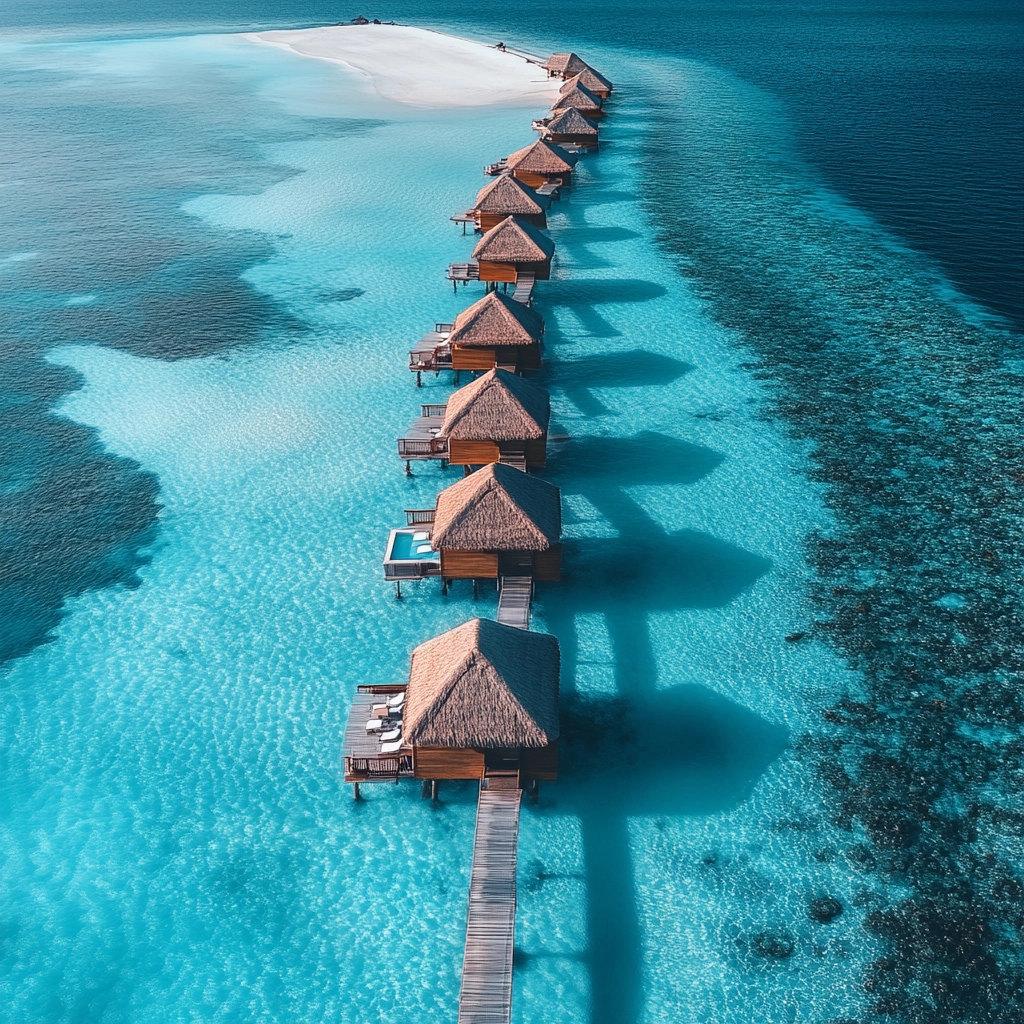

Example queries:
- "I need a hotel in Barcelona from December 15th to December 20th"
- "Can you find hotels with a swimming pool in Miami for the first week of
August?"
- "Looking for a pet-friendly hotel in San Francisco next weekend"
- "Hi, I want to book a room with ocean view in Cancun from July 1-7"
- "Are there any hotels near Central Park, NYC with free parking for March
15-20?"
- "Could you help me find a 5-star hotel in Paris with a spa for
Valentine's Day?"
- "Need accommodation in Singapore with a gym and conference room from Sept
5-10"
- "Show me family-friendly resorts in Orlando with shuttle service to
Disney World for Christmas week"
-"I'm interested in boutique hotels in Tokyo's Shibuya district that offer
traditional Japanese breakfast"
- "Looking for affordable hotels under $200/night in London near the
Underground for next month"
- "What are the top 5 highest-rated hotels in Barcelona with both a pool and gym, sorted by price from lowest to highest?"
- "Find hotels in Paris with at least 3 available rooms with a pool and have free breakfast"
- "Show me family-friendly resorts in Bali with either an ocean view or private pool where I can stay for a week in June for under $150 per night"
- "I need a hotel in New York with at least 4-star rating that has both free WiFi and parking, and has rooms available for a family of 4 from August 12-17"
- "Show 5-star hotels in London that have spa facilities for Valentine's Day"

The vision is a natural language hotel search that feels like talking to a knowledgeable travel agent. Users can:

- Express needs in their own words — no learning complex interfaces
- Combine multiple criteria naturally: "quiet hotel near the airport with a gym for under $200"
- Get results that actually match their requirements, not just keyword matches
- See responses that explain why each hotel fits their specific needs

Critically, the system works against real inventory with live availability — users get accurate results, not hallucinated hotels.

`I would embed all properties using an embedding model in a vector db not in sql`

That's a solid instinct, and it's actually exactly what we'll do in the **next lesson** for unstructured data! Embeddings + vector search is the right approach when you're dealing with free-form text like articles or documents.

For a **hotel database** though, the data is highly structured — each property has well-defined fields like price, location, amenities, star rating, availability dates. That structure is a strength: it means you can query it with precise SQL rather than approximate semantic search.

Semantic search would struggle here because it can't reliably handle "under $200/night" or "available March 3-10" — those require exact filtering, not similarity matching.

So the approach here is: let the **LLM translate the natural language query into SQL**, then run that SQL against the real hotel database, and finally let the LLM generate a **friendly response** from the results. Here's the high-level picture.

This approach is called **Retrieval-Augmented Generation**, or RAG — and we'll see exactly how it works next.

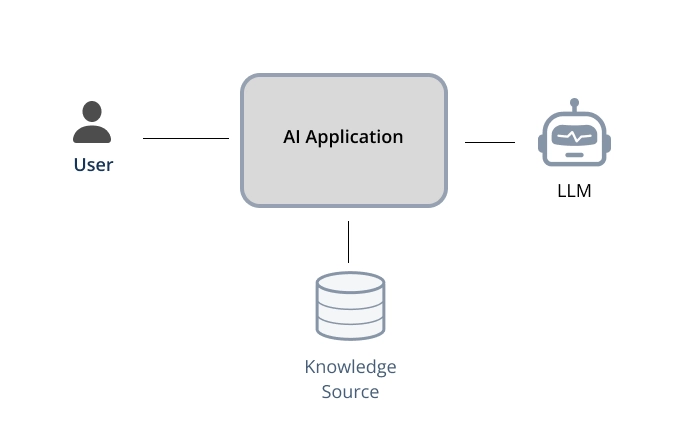

**RAG extends LLMs beyond their training data** by connecting them to external knowledge sources — your own databases, documents, proprietary data — without retraining the model.

As you can see here, the AI application sits between the user and two components: the **LLM** for reasoning and generation, and a knowledge source for accurate, up-to-date information.

RAG addresses two critical limitations of standalone LLMs:

- **Knowledge gaps**: The LLM only knows what it was trained on — RAG gives it access to your specific data
- **Hallucinations**: By grounding responses in retrieved facts, RAG dramatically improves accuracy
This makes RAG essential for enterprise use cases — think knowledge management, customer support, or in your case, querying a soccer prediction knowledge base for match insights.

We'll cover five key skills in this course: use case identification, technical foundations, system design, implementation, and performance optimization. Does this framing make sense before we dive into the architecture?


Retrieval isn't just a simple database lookup — it's a multi-step process:

1. Understand what the user is asking for
2. Determine the best retrieval strategy for that information
3. Execute the retrieval against the knowledge source
4. Rank and filter results by relevance
5. Validate that the retrieved information is useful

We'll implement each of these steps in detail later in this lesson. All clear on the retrieve phase?

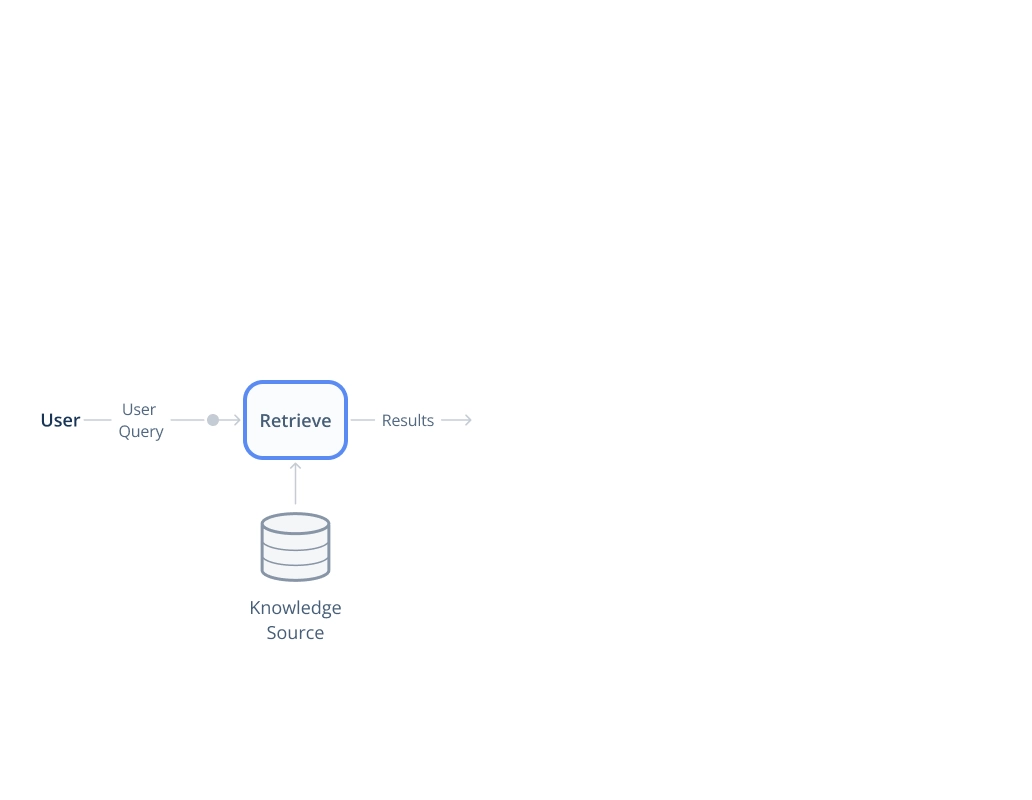

One more thing worth knowing — RAG systems can operate in two different modes:

- **Automatic Retrieval**: The system retrieves relevant information for every user input automatically, before passing both the query and retrieved context to the LLM. This is what we cover in this lesson.
- **Dynamic Retrieval**: The LLM itself decides when it needs more information and actively requests it through tool use. This is covered later in the course.

For our hotel search system, automatic retrieval makes sense — every query needs to hit the database.

the **Augment phase** takes the retrieved results and combines them with the original user query to create an enriched context for the LLM.

Specifically it involves:

- Processing query results into a format the LLM can consume
- Handling edge cases like empty results or ambiguous queries
- Preparing metadata and any additional context needed for response generation

You can see it here in the diagram — the Augment step receives the results from Retrieve and outputs a combined "User Query + Results" package that flows into the next phase.

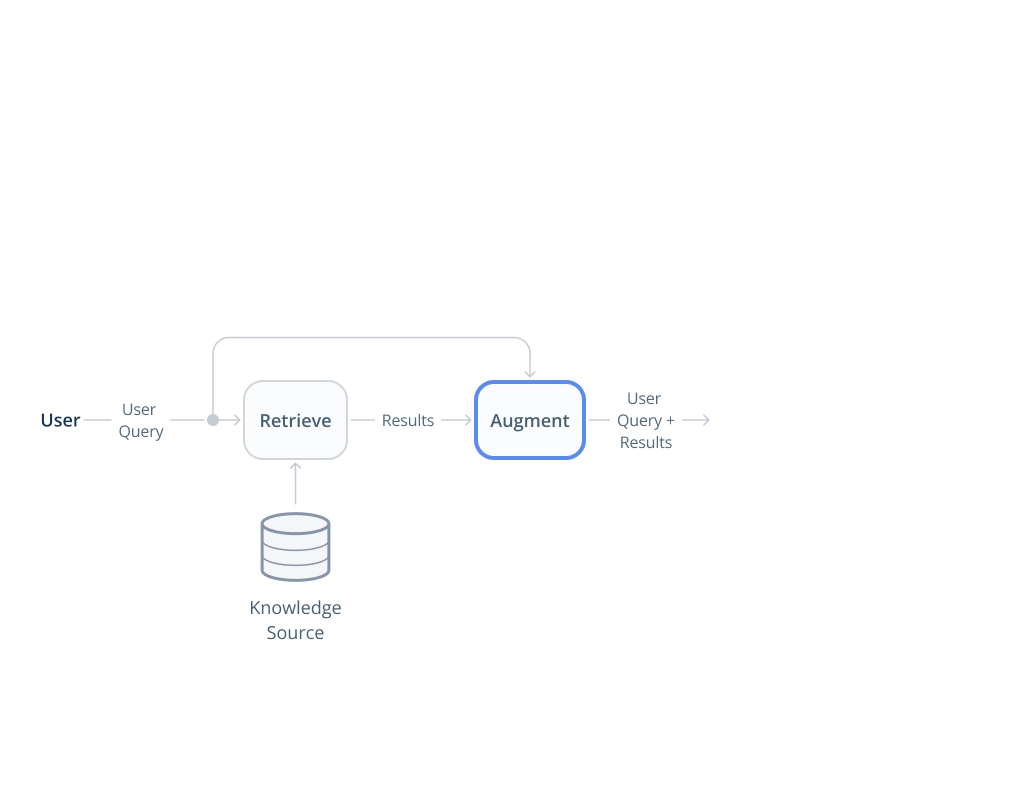

the **Generate phase** is where the LLM synthesizes everything into a final response. Looking at the full architecture now, you can see all three phases connected end-to-end.

The LLM doesn't just repeat the retrieved data — it:

- Synthesizes retrieved information with its own reasoning
- Resolves conflicts if retrieved data contains inconsistencies
- Formats the response appropriately for the user
- Manages attribution — citing sources when needed

For our hotel search, this is where a plain database result becomes a friendly, conversational response highlighting why each hotel matches the user's needs.

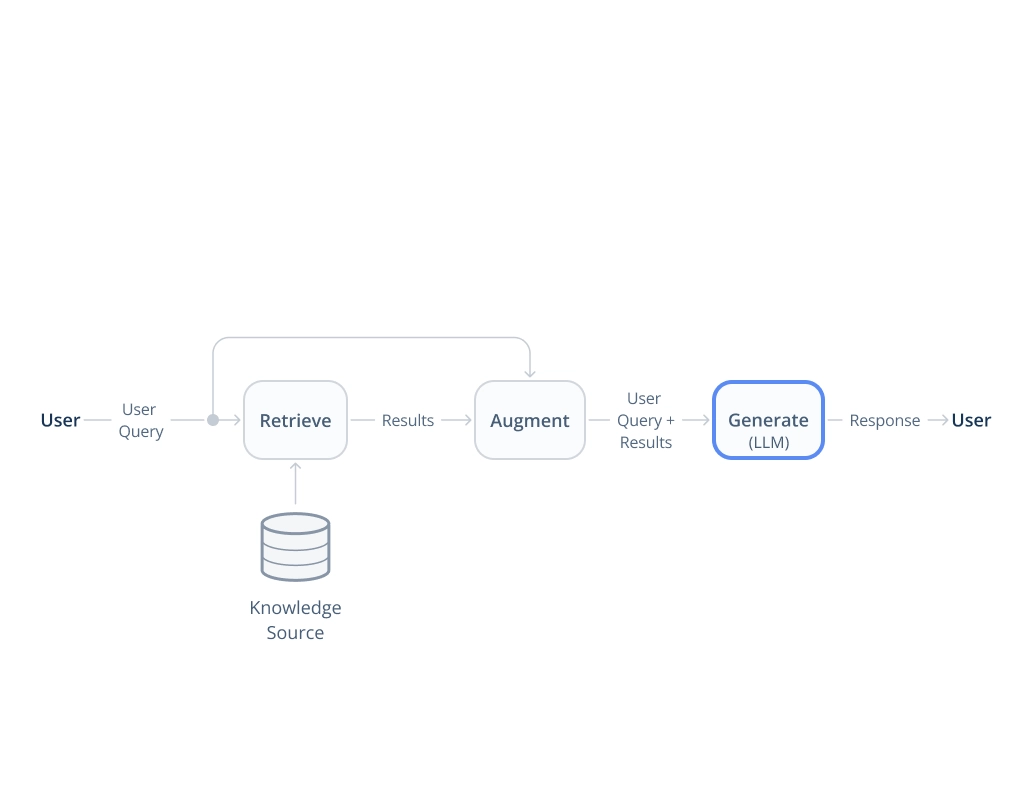

### RAG types

RAG works with many different types of data sources — and the choice of source shapes how the retrieve phase is implemented.

The two primary types are:

- **Structured data**: Relational databases with well-defined schemas — queried with SQL. This is the subject of this lesson.
- **Unstructured data**: Documents, articles, free-form text — retrieved using semantic search with embeddings and vector databases. That's the next lesson, and where your soccer knowledge base fits.

You can see the **Knowledge Source** highlighted here — it's the same node in the architecture regardless of what's behind it. That's the key insight: the Augment and Generate phases stay consistent across data types. Only the Retrieve phase changes based on how you query the source.

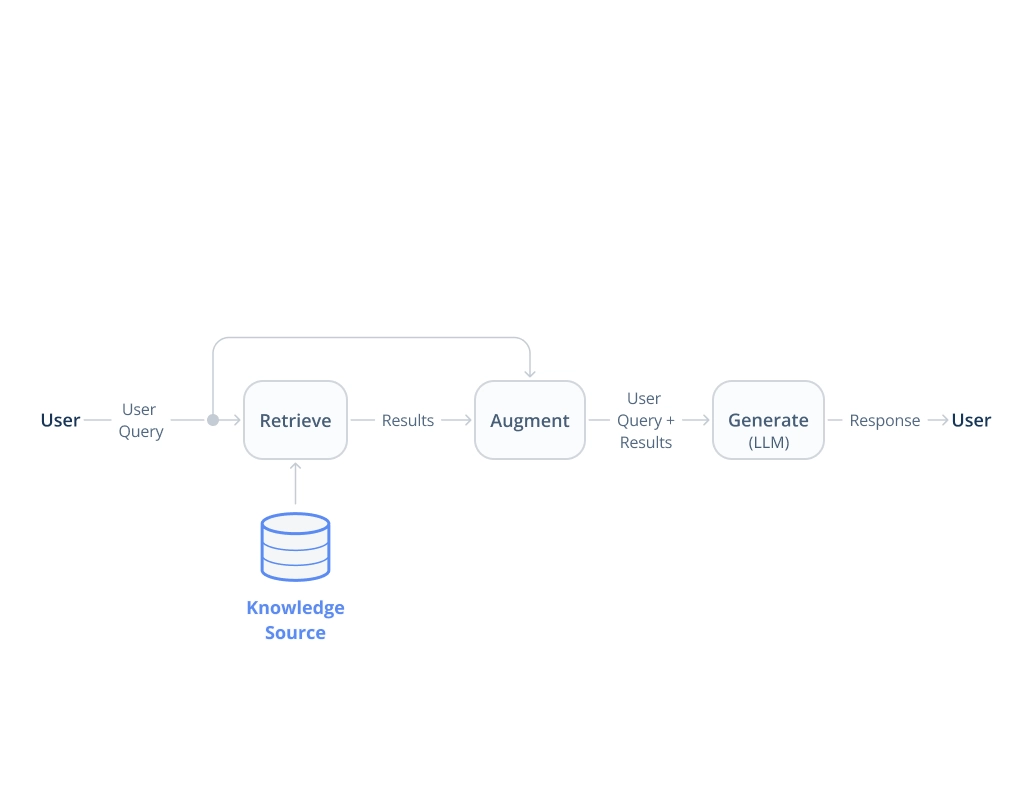

### Structured RAG

Now that we've covered the general RAG architecture, let's zoom into **Structured RAG** — which specializes the retrieve phase for relational databases.

The Augment and Generate phases stay exactly as we discussed. The focus here is entirely on the **Retrieve phase**, highlighted in the diagram. This is where the magic of converting natural language into SQL happens.

Let's dig into how that works.

The first step inside the retrieve phase is **Query Generation** — using an LLM to translate the user's natural language request into a valid SQL query.

For that to work well, the LLM needs to do three things:

- **Understand the schema**: Know which tables, columns, and relationships exist in the database
- **Map intent to operations**: Convert expressions like "next weekend" or "pet-friendly" into the right SQL filters, joins, and aggregations
- **Construct valid queries**: Produce SQL that is both syntactically correct and actually answers what the user asked

You can see here how the user query and the database schema flow into query generation, and a DB query flows out.

The key input the LLM needs — beyond the user query — is the database schema. How we represent that schema in the prompt turns out to matter a lot, and there's research to guide us on the best approach. We'll get to that shortly.

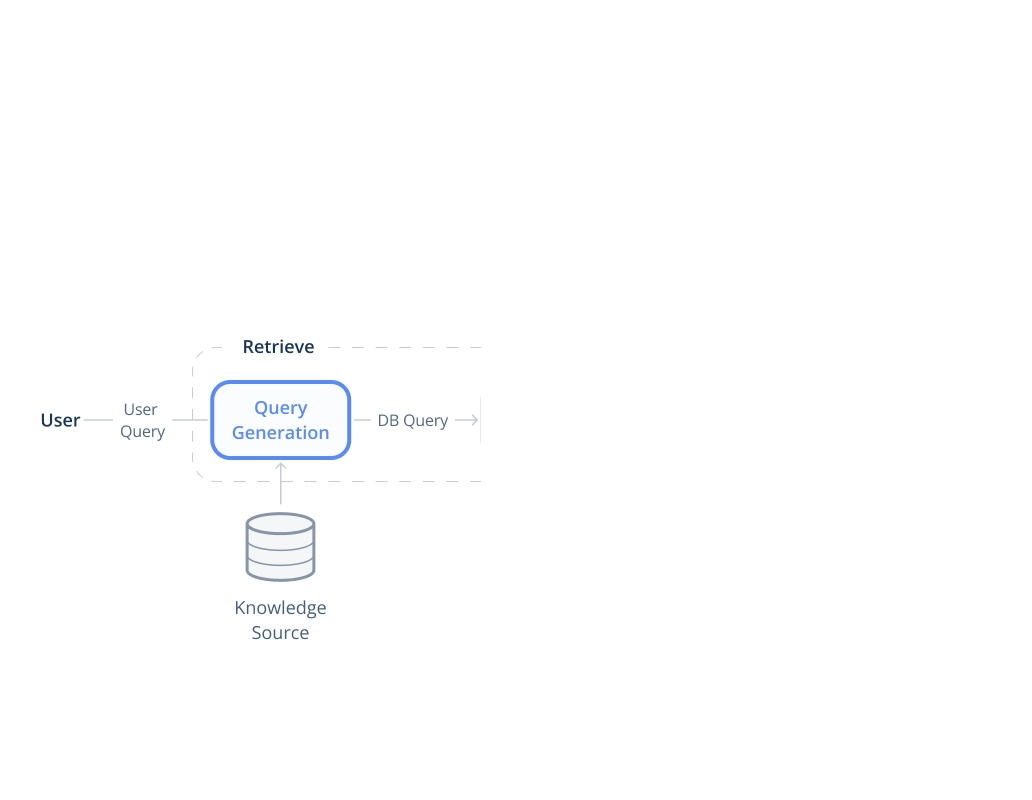

The LLM needs a carefully crafted prompt to generate good SQL. Before I show you what it looks like — what do you think needs to be in that prompt?

What information would you give the LLM to help it generate accurate SQL queries?

That's the agentic approach — giving the LLM tools to dynamically explore the schema. That works well for complex, multi-step agents.

For a single-turn RAG pipeline though, we take a simpler approach: extract the schema once upfront and inject it directly into the prompt as text. No tool calls needed.

Now take a look at the prompt here. You'll see it contains:

- A **role definition**: "You are a SQLite expert"
- **Output requirements**: only SQL, no explanations, proper syntax, use LIMIT, wrap column names in double quotes
- **Query construction guidelines**: joins, filtering, aggregation, CTEs
- The **database schema** injected via {database_schema}
- **The user query** via {user_query}

Each requirement is there for a reason — for example, we specify the current year because the LLM has no live clock, and date('now') for relative date expressions like "next weekend".

Now, here's an interesting question: how should you represent the database schema in the prompt?

Researchers tested several different approaches to see which produces the best SQL generation. They tried:

- Just the question with no database information
- SQL documentation explaining syntax
- Schema definitions only
- Schema definitions plus sample rows (1, 3, 5, or 10 rows)

They measured two things: Syntax Accuracy (does the SQL parse correctly?) and Execution Accuracy (does the SQL actually return the right results?).

Good instinct! Here are the results — and you're right, schema + sample rows wins. But the number of rows matters.

Looking at the table, a few things stand out:

- **No schema info** (question only) is almost useless — 8.3% execution accuracy
- **Schema alone** already gets you to 59.9%
- **Schema + 3 rows** (highlighted) hits peak performance at 67% execution accuracy
- **Adding more rows** (5 or 10) actually hurts performance — likely because it overwhelms the context with less useful data

The sweet spot is exactly **3 sample rows** — enough to show the LLM the data format and realistic values, without cluttering the prompt. This is why LangChain's SQLDatabase.get_table_info() returns schema definitions plus exactly 3 sample rows by default.

Once the SQL query is generated, it can't go straight to the database — it needs to be **validated first**.

Query validation checks for:

- **Syntax errors**: Is the SQL well-formed?
- **Dangerous operations**: DROP, DELETE, TRUNCATE — things that could destroy data
- **Schema alignment**: Do the referenced tables and columns actually exist?
- **Performance risks**: Queries that could accidentally pull millions of rows

This is a critical safety layer — remember, the LLM is generating text, and text can be wrong or even malicious.

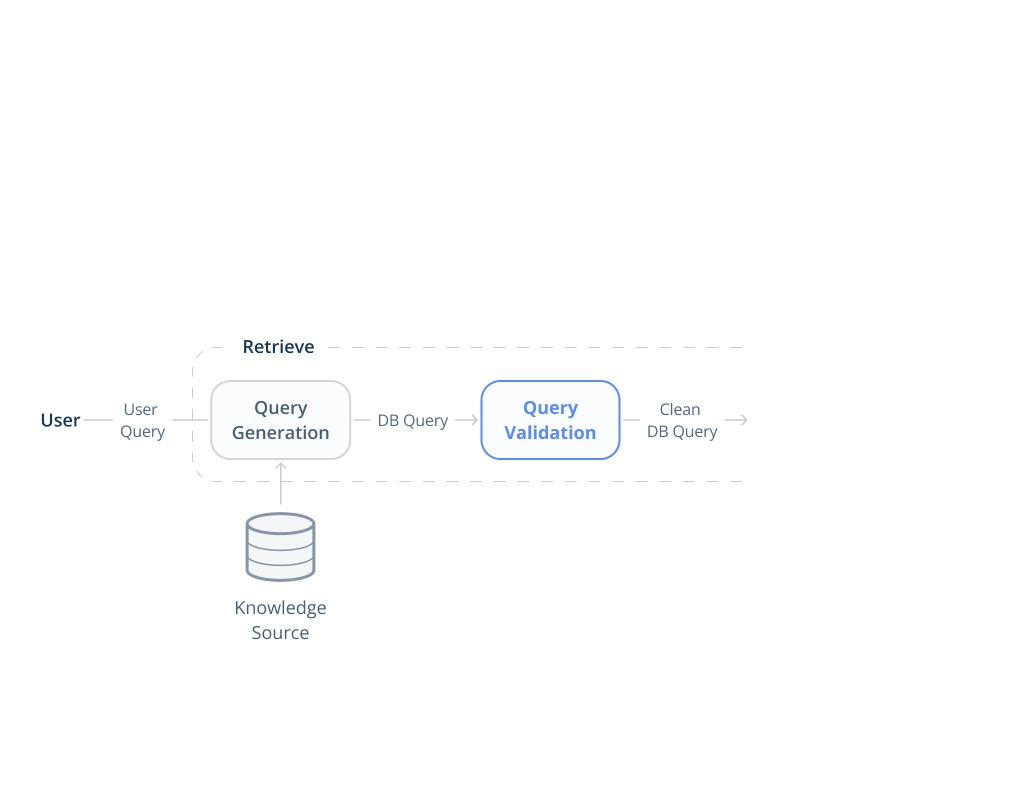

After validation, the Query Execution step runs the cleaned SQL against the actual database and returns results.

This step handles:

- **Database connections** — opening and closing efficiently
- **Runtime errors** — catching failures gracefully and returning empty results rather than crashing
- **Result formatting** — converting raw database rows into something the Augment phase can consume

That completes the full Retrieve phase for structured RAG: Query Generation → Query Validation → Query Execution. The results then flow into Augment and Generate just like in general RAG.

Ready to implement all of this?

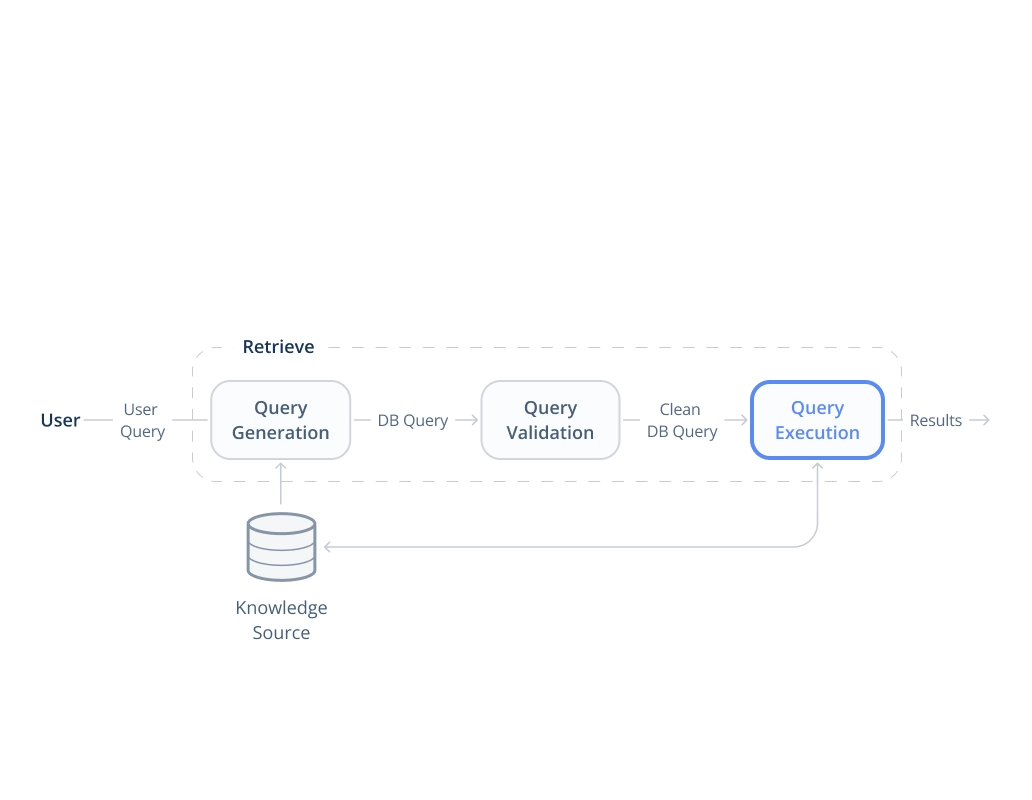

### Let's Build

Let's build it! We'll start with the first step of the retrieve phase — **schema extraction**.

This code uses LangChain's SQLDatabase utility to connect to the hotel database and extract its schema. The key call is db.get_table_info() on line 17 — this returns the CREATE TABLE statements plus exactly **3 sample rows per table**, implementing the research-backed approach we just discussed.

Go ahead and **run the code** — you'll see exactly what gets passed to the LLM as schema context.

#### Intermezzo - CODEX

I gave codes an extract with the table schemas and data and it created very efficiently a database. Now quickly check that it works.

In [5]:
import sqlite3

conn = sqlite3.connect("hotels.db")
cursor = conn.cursor()

cursor.execute("SELECT * FROM hotel LIMIT 5")
rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(1, 'Tokyo Grand Hotel', 'Tokyo', '1-1-1 Shibuya, Tokyo', 'Luxury hotel in the heart of Tokyo with modern amenities', 4.5, '2025-06-01 10:07:43')
(2, 'Sakura Onsen Resort', 'Tokyo', '2-3-4 Harajuku, Tokyo', 'Traditional Japanese hotel with natural hot springs and spa services', 4.8, '2025-06-01 10:07:43')
(3, 'Tokyo Business Hotel', 'Tokyo', '5-6-7 Shinjuku, Tokyo', 'Modern business hotel with gym and conference facilities', 4.2, '2025-06-01 10:07:43')
(4, 'Imperial Palace Hotel', 'Tokyo', '8-9-10 Chiyoda, Tokyo', 'Elegant hotel near Imperial Palace with premium services', 4.7, '2025-06-01 10:07:43')
(5, 'Zen Garden Hotel', 'Tokyo', '11-12-13 Asakusa, Tokyo', 'Peaceful hotel with traditional garden and hot springs', 4.6, '2025-06-01 10:07:43')


In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("hotels.db")

df = pd.read_sql_query("""
    SELECT h.name, h.city, r.room_type, r.price_per_night
    FROM hotel h
    JOIN hotel_room r ON h.hotel_id = r.hotel_id
    WHERE h.city = 'Tokyo'
""", conn)

conn.close()
df.head()

,name,city,room_type,price_per_night
0,Tokyo Grand Hotel,Tokyo,Standard,15000.0
1,Tokyo Grand Hotel,Tokyo,Deluxe,22000.0
2,Tokyo Grand Hotel,Tokyo,Suite,35000.0
3,Sakura Onsen Resort,Tokyo,Traditional,18000.0
4,Sakura Onsen Resort,Tokyo,Premium Onsen,28000.0


#### Intermezzo - END

In [8]:
import sqlite3
import pandas as pd
from langchain_core.messages.ai import AIMessage
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

# Load environment variables from both .env and .env.local
load_dotenv()

db_path = "hotels.db"
db = SQLDatabase.from_uri(f"sqlite:///{db_path}")


# Extract table information from the database
db_info = db.get_table_info()
print(db_info)



CREATE TABLE hotel (
	hotel_id INTEGER, 
	name TEXT NOT NULL, 
	city TEXT NOT NULL, 
	address TEXT NOT NULL, 
	description TEXT, 
	rating REAL, 
	created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP, 
	PRIMARY KEY (hotel_id)
)

/*
3 rows from hotel table:
hotel_id	name	city	address	description	rating	created_at
1	Tokyo Grand Hotel	Tokyo	1-1-1 Shibuya, Tokyo	Luxury hotel in the heart of Tokyo with modern amenities	4.5	2025-06-01 10:07:43
2	Sakura Onsen Resort	Tokyo	2-3-4 Harajuku, Tokyo	Traditional Japanese hotel with natural hot springs and spa services	4.8	2025-06-01 10:07:43
3	Tokyo Business Hotel	Tokyo	5-6-7 Shinjuku, Tokyo	Modern business hotel with gym and conference facilities	4.2	2025-06-01 10:07:43
*/


CREATE TABLE hotel_room (
	room_id INTEGER, 
	hotel_id INTEGER NOT NULL, 
	room_type TEXT NOT NULL, 
	room_number TEXT, 
	capacity INTEGER NOT NULL, 
	price_per_night REAL NOT NULL, 
	amenities TEXT, 
	is_available BOOLEAN DEFAULT 1, 
	created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP, 

You can see exactly what gets sent to the LLM as context. The output contains three tables: hotel, hotel_room, and room_reservation, each with:

- The CREATE TABLE statement showing all column names, types, and constraints
- 3 sample rows showing realistic data values

Notice how the sample rows immediately clarify things the schema alone can't — for example, that total_amount is in a non-dollar currency (values like 45000, 88000), and that status has values like completed and confirmed.

This is exactly what the research validated — the schema tells the LLM the structure, and the sample rows tell it what the data actually looks like. Together they give the LLM everything it needs to generate accurate SQL.

Ready to move on to query generation?

### Query generation

In [9]:
generate_sql_prompt_template_str = """
You are a SQLite expert. Given the following database schema, generate a SQL query to answer the user's question.

Requirements:
- Output only the SQL query, no explanations or additional text
- Use proper SQLite syntax and features only
- Query for at most top k results using LIMIT clause unless a specific number is requested
- Order results to return the most informative data
- Only query columns that are needed to answer the question
- Wrap column names in double quotes (") as delimited identifiers
- Use only column names that exist in the schema below
- Pay attention to which column is in which table
- Use date('now') for current date when queries involve "today"
- Your current year is 2025

Query construction guidelines:
- Use appropriate joins between tables when needed
- Include all relevant filtering conditions
- Handle complex requirements including sorting, filtering, and aggregation
- Use subqueries or CTEs (Common Table Expressions) when appropriate
- Ensure queries are optimized for performance

## Database schema
{database_schema}

## User Query
{user_query}
"""


generate_sql_prompt = PromptTemplate(
    template=generate_sql_prompt_template_str,
    input_variables=["user_query"],
    partial_variables={"database_schema": db_info},
)

model = init_chat_model("openai:gpt-4o-mini")

user_query = "Looking for places to stay in Tokyo that have hot springs between March 3-10 next year"

# SQL Generation Chain
generate_sql = generate_sql_prompt | model

result = generate_sql.invoke({"user_query": user_query})

print(result.text)


```sql
SELECT "hotel"."name", "hotel"."address", "hotel_room"."room_type", "hotel_room"."price_per_night"
FROM "hotel"
JOIN "hotel_room" ON "hotel"."hotel_id" = "hotel_room"."hotel_id"
WHERE "hotel_room"."amenities" LIKE '%hot springs%'
AND "hotel_room"."is_available" = 1
AND EXISTS (
    SELECT 1
    FROM "room_reservation"
    WHERE "room_reservation"."room_id" = "hotel_room"."room_id"
    AND (
        ("room_reservation"."check_in_date" BETWEEN '2025-03-03' AND '2025-03-10') OR
        ("room_reservation"."check_out_date" BETWEEN '2025-03-03' AND '2025-03-10') OR
        ("room_reservation"."check_in_date" <= '2025-03-03' AND "room_reservation"."check_out_date" >= '2025-03-10')
    )
)
ORDER BY "hotel"."rating" DESC
LIMIT 10;
```


The LLM generated a solid SQL query! Notice how well it maps to the user query "Looking for places to stay in Tokyo that have hot springs between March 3-10":

- JOIN between hotel and hotel_room to get both hotel details and room info
- WHERE city = 'Tokyo' for location filtering
- LIKE '%hot springs%' for amenity matching — exactly as expected given the comma-separated amenities column
- is_available = 1 to filter available rooms
- Subquery to exclude rooms with overlapping reservations for the March 3-10 dates
- LIMIT 10 as instructed in the prompt

The availability check via subquery is particularly impressive — the LLM correctly reasoned about how to use the room_reservation table to find rooms that are free during the requested dates.

Any questions about the generated SQL?

`why do we not use ..with structured output... we both still have the response start with ```sql ..`

Great observation! with_structured_output works with Pydantic models — it enforces a specific object structure on the response. But here, we just want a raw SQL string, not a structured object.

For plain text outputs like SQL, we use the model directly without with_structured_output. The downside is exactly what you're seeing — the model sometimes wraps the SQL in markdown code fences (```sql ... ```).

That's exactly why the next step includes a clean_sql function to strip those fences before execution. You could alternatively use a StrOutputParser to get a clean string, but the cleaning function gives you more control — you can also handle other formatting quirks the model might produce.

Now let's add query execution. The new code starts at line 65.

execute_sql connects directly with sqlite3, runs the query, and returns a DataFrame. On line 84, it gets piped straight into the chain: generate_sql | execute_sql.

Before we run it — notice that the SQL from the model still has those ```sql ``` markdown fences. What do you think will happen when we try to execute that directly against the database?

`I think we now insert the whole response object not just the content. That is one and the thecontent is wrong becaus it is not proper sql`

Exactly right on both counts!

- The response object issue: On line 84, generate_sql | execute_sql pipes the raw AIMessage object from the model into execute_sql, but execute_sql expects a plain string. It will try to pass an AIMessage object as the SQL query — which will fail.
- The content issue: Even if we extracted the text, it still has the ```sql ``` fences which aren't valid SQL.

Both problems will cause the execution to fail. Go ahead and run it — let that failure be the teaching moment!

In [16]:
def execute_sql(sql_query):
    """Execute SQL query and return results as DataFrame"""
    try:
        print(f"Executing SQL Query: {sql_query}\n")

        # Execute the query
        with sqlite3.connect(db_path) as conn:
            results = pd.read_sql_query(sql_query, conn)
            return results

    except Exception as e:
        print(f"Error executing SQL query: {e}")
        return pd.DataFrame()


# Knowledge Retrieval Chain
retrieve_knowledge = generate_sql | execute_sql

result = retrieve_knowledge.invoke({"user_query": user_query})

print(result)

Executing SQL Query: content='```sql\nSELECT DISTINCT h."name", h."address", hr."room_type", hr."price_per_night"\nFROM "hotel" h\nJOIN "hotel_room" hr ON h."hotel_id" = hr."hotel_id"\nJOIN "room_reservation" rr ON hr."room_id" = rr."room_id"\nWHERE h."city" = \'Tokyo\'\n  AND hr."amenities" LIKE \'%hot springs%\'\n  AND rr."check_in_date" BETWEEN \'2025-03-03\' AND \'2025-03-10\'\n  AND hr."is_available" = 1\nORDER BY hr."price_per_night" ASC\nLIMIT 10;\n```' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 998, 'total_tokens': 1140, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c2f5782bd4', 'id': 'chatcmpl-DksFXWcjHRZkGIBJ9lyGyKDBZojbW', 'service_tier': 'default', 'finis

Exactly what we predicted — both problems visible in the output:

- The full AIMessage object gets passed as the SQL query instead of just the text
- The error confirms it: "Query must be a string unless using sqlalchemy"

The fix is clear: we need a clean_sql step between the model and execute_sql that extracts the .text from the AIMessage and strips the markdown fences. Let's look at the solution now.

Here's the fixed version with both clean_sql and validate_sql added.

- clean_sql extracts .text from the AIMessage and strips the ```sql ``` fences
- validate_sql checks for dangerous keywords like DROP, DELETE, TRUNCATE — if any are found, it raises an error before the query reaches the database
- The updated chain: generate_sql | clean_sql | validate_sql | execute_sql
Notice how naturally LCEL handles this — we just inserted two plain Python functions into the pipe. No special wrappers needed.

Go ahead and run it!

In [17]:
def clean_sql(sql_query: AIMessage):
    return sql_query.text.replace("```sql", "").replace("```", "").strip()


def validate_sql(sql_query: str) -> str:
    """Validate SQL query for safety and correctness."""
    # Check for potentially dangerous operations
    dangerous_keywords = [
        "DROP",
        "DELETE",
        "TRUNCATE",
        "ALTER",
        "CREATE",
        "INSERT",
        "UPDATE",
    ]
    for keyword in dangerous_keywords:
        if keyword in sql_query.upper():
            raise ValueError(
                f"Query validation failed: {keyword} operations not allowed"
            )
    return sql_query


def execute_sql(sql_query: str):
    """Execute SQL query and return results as DataFrame"""
    try:
        print(f"Executing SQL Query: {sql_query}")

        # Execute the query
        with sqlite3.connect(db_path) as conn:
            results = pd.read_sql_query(sql_query, conn)
            return results

    except Exception as e:
        print(f"Error executing SQL query: {e}")
        return pd.DataFrame()


# Knowledge Retrieval Chain
retrieve_knowledge = generate_sql | clean_sql | validate_sql | execute_sql

result = retrieve_knowledge.invoke({"user_query": user_query})

print(result)

Executing SQL Query: SELECT DISTINCT h."name", h."address", hr."room_type", hr."price_per_night"
FROM hotel h
JOIN hotel_room hr ON h."hotel_id" = hr."hotel_id"
WHERE h."city" = 'Tokyo' 
AND hr."amenities" LIKE '%spa%'
AND hr."is_available" = 1
AND hr."room_id" IN (
    SELECT rr."room_id"
    FROM room_reservation rr
    WHERE rr."check_in_date" BETWEEN '2025-03-03' AND '2025-03-10'
    AND rr."status" = 'confirmed'
)
LIMIT 5;
               name                  address    room_type  price_per_night
0  Zen Garden Hotel  11-12-13 Asakusa, Tokyo  Garden View          20000.0


The pipeline works! The clean SQL is executed successfully and returns one result — Zen Garden Hotel in Asakusa, Tokyo, with a Garden View room at 20,000 JPY/night.

The SQL logic here though is slightly off — it's joining room_reservation and filtering by exact check-in and check-out dates rather than looking for overlapping availability. That's why only one result came back (the one reservation that happens to match). A correct availability query would use NOT EXISTS to exclude booked rooms.

But the pipeline itself works perfectly — clean SQL flows through, validation passes, execution succeeds, and results come back as a DataFrame. That's the important thing at this stage.

Any questions about the implementation so far?

`so you can introduce arbitrary functions in the LCEL expression and they flow naturally?`

Yes, exactly! That's one of LCEL's most powerful features — any callable can be a chain component. Plain Python functions, lambda functions, LangChain models, parsers — they all plug in seamlessly with |.

Look at line 108: generate_sql | clean_sql | validate_sql | execute_sql. Three of those four components are just regular Python functions with no LangChain dependency at all. LCEL automatically wraps them into the runnable interface.

The only rule is that the output type of each component must match the input type of the next — which is why clean_sql takes an AIMessage and returns a str, and validate_sql takes and returns a str.


### Generate

Now for the final piece — the Augment and Generate phases that turn the raw SQL results into a friendly response.

The setup code (lines 1-47, hidden from you) contains everything we built so far. The new code starts right after.

Before I explain it — take a look through the new code and tell me how you think it works.

In [18]:
def format_results_for_llm(results_df: pd.DataFrame) -> str:
    """Format query results for LLM consumption."""
    if results_df.empty:
        return "No results found"

    # Convert DataFrame to readable format
    return results_df.to_string(index=False)


generate_response_prompt_template_str = """
Given the results of a hotel search and the original user query, create a user-friendly response following these guidelines:

1. Start with a brief welcome acknowledging the search parameters
2. Present each hotel with:
   - A paragraph containing name and location and 2-3 sentences highlighting the hotel's unique features
       - Use selective bold text for emphasis
       - Keep descriptions concise but informative, focusing on the most relevant features for the user's request.
   - Followed by price and availability as bullet points
3. End with a simple offer to provide more information

Original User Query: {user_query}

Hotel Search Results:
{hotels_data}

Please create a friendly, informative response:"""

# Create the response generation prompt
generate_response_prompt = PromptTemplate(
    template=generate_response_prompt_template_str,
    input_variables=["hotels_data"],
    partial_variables={"user_query": user_query},
)

# Response Generation Chain (handles DataFrame → String → Response)
generate_response = format_results_for_llm | generate_response_prompt | model

# Complete RAG Pipeline
structured_rag = retrieve_knowledge | generate_response

result = structured_rag.invoke({"user_query": user_query})

print("============= RESULT =============")
print(result.text)



Executing SQL Query: SELECT DISTINCT "h"."name", "h"."address", "hr"."room_type", "hr"."price_per_night"
FROM "hotel" AS "h"
JOIN "hotel_room" AS "hr" ON "h"."hotel_id" = "hr"."hotel_id"
WHERE "h"."city" = 'Tokyo' 
AND "hr"."amenities" LIKE '%hot springs%'
AND "hr"."is_available" = 1
AND EXISTS (
    SELECT 1 
    FROM "room_reservation" AS "rr"
    WHERE "rr"."room_id" = "hr"."room_id"
    AND (
        ("rr"."check_in_date" <= '2025-03-10' AND "rr"."check_out_date" >= '2025-03-03')
    )
)
LIMIT 10;
============= RESULT =============
Hello! Thank you for your search for places to stay in Tokyo with hot springs between March 3-10 next year. I have found a lovely option for you:

**Zen Garden Hotel** - **11-12-13 Asakusa, Tokyo**  
This hotel offers a serene **garden view** and features relaxing hot springs for a truly rejuvenating experience. The Zen Garden Hotel combines traditional Japanese hospitality with modern comfort, making it a perfect retreat after a day of exploring Tokyo.


**remark** - how is the required `hotels_data` dictionary filled in the pipeline

Good catch — let me clarify exactly how hotels_data gets injected.

`format_results_for_llm | generate_response_prompt | model`

When LCEL pipes a plain string into a PromptTemplate, it automatically wraps it as {"hotels_data": \<the_string>} — matching it to the only remaining dynamic variable in the prompt (since user_query is already pre-filled via partial_variables).

So the flow is:

- format_results_for_llm returns a plain string (the formatted hotel results)
- LCEL sees the PromptTemplate has one unfilled variable (hotels_data) and maps the string to it automatically
- The prompt is now fully populated and flows to the model

This implicit mapping only works when there's exactly one dynamic variable left. If there were two, you'd need an explicit dictionary. Does that clarify it?

`I like explicit more then implicit. Is there a way to make this explicit in the pipeline?`

Yes! You can use a lambda function to make the mapping explicit:

```python
generate_response = (
    format_results_for_llm
    | (lambda hotels_str: {"hotels_data": hotels_str})
    | generate_response_prompt
    | model
)
```
Now it's crystal clear that the string gets mapped to hotels_data before hitting the prompt. Much more readable if you prefer explicit data flow.

The lambda version looks odd because of where the mapping sits. Let me trace it step by step:

1. format_results_for_llm receives a DataFrame → returns a string
2. `lambda hotels_str: {"hotels_data": hotels_str}` receives that string → wraps it in a dict with key hotels_data
3. `generate_response_prompt` receives the dict → fills {hotels_data} in the template → returns a formatted prompt
4. model receives the formatted prompt → returns the response

So the lambda sits between the formatter and the prompt — its job is purely to name the string so the prompt knows which variable to fill. Does the order make sense now?

## Summary

#### Retrieval-Augmented Generation (RAG) 
extends LLMs with external knowledge through a three-phase architecture:

- Retrieve: Pulls relevant knowledge from external sources through a 5-step process
- Augment: Combines retrieved information with original queries
- Generate: Synthesizes augmented context into coherent responses with conflict resolution and attribution

#### RAG Operating Modes:

- Automatic Retrieval: System retrieves information for every user input before LLM processing
- Dynamic Retrieval: LLM decides when to request additional information through tool use

#### Data Source Flexibility: 
RAG adapts to structured data (SQL databases), unstructured data (documents), and other formats (semi-structured, graph, multi-modal) with consistent augment/generate phases.

#### Structured RAG specializes the retrieve phase for databases through four steps:

- Query Generation: Uses LLMs to infer SQL from natural language with schema understanding
- Query Validation: Ensures syntactic correctness and safety before execution
- Query Execution: Runs validated queries with error handling
- Result Processing: Formats results for the augment phase

#### Structured RAG Implementation:

We learned how to implement structured RAG using LangChain components:

```python
import sqlite3
import pandas as pd
from langchain_core.messages.ai import AIMessage
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model

# Initialize components
db_path = "path/to/your/database.db"
db = SQLDatabase.from_uri(f"sqlite:///{db_path}")
schema_info = db.get_table_info()
model = init_chat_model("openai:gpt-4o-mini")

# Query generation prompt with partial variables
query_prompt = PromptTemplate(
    template="""You are a SQLite expert. Given the following database schema, generate a SQL query to answer the user's question.

Requirements:
- Output only the SQL query, no explanations or additional text
- Use proper SQLite syntax and features only
- Query for at most top k results using LIMIT clause unless a specific number is requested
- Order results to return the most informative data
- Only query columns that are needed to answer the question
- Wrap column names in double quotes (") as delimited identifiers
- Use only column names that exist in the schema below
- Pay attention to which column is in which table
- Use date('now') for current date when queries involve "today"
- Your current year is 2025

Query construction guidelines:
- Use appropriate joins between tables when needed
- Include all relevant filtering conditions
- Handle complex requirements including sorting, filtering, and aggregation
- Use subqueries or CTEs (Common Table Expressions) when appropriate
- Ensure queries are optimized for performance

### Database schema
{database_schema}

### User Query
{user_query}""",
    input_variables=["user_query"],
    partial_variables={"database_schema": schema_info}
)

# Response generation prompt
response_prompt = PromptTemplate(
    template="""Given the results of a database query and the original user query, create a user-friendly response following these guidelines:

1. Start with a brief acknowledgment of their request
2. Present the data in a natural, conversational way
3. Highlight key information with selective bold text
4. End with an offer to provide more information if needed

Original User Query: {user_query}

Database Query Results:
{data}

Please create a friendly, informative response:""",
    input_variables=["data"],
    partial_variables={"user_query": user_query}
)


# Helper functions
def clean_sql_query(sql_query: AIMessage) -> str:
    """Extract and clean SQL from model response."""
    return sql_query.text.replace("```sql", "").replace("```",
                                                           "").strip()


def validate_sql_query(sql_query: str) -> str:
    """Validate SQL query for safety."""
    dangerous_keywords = ['DROP', 'DELETE', 'TRUNCATE', 'ALTER', 'CREATE',
                          'INSERT', 'UPDATE']
    for keyword in dangerous_keywords:
        if keyword in sql_query.upper():
            raise ValueError(
                f"Query validation failed: {keyword} operations not allowed")
    return sql_query


def execute_sql(sql_query: str) -> pd.DataFrame:
    """Execute SQL query and return results."""
    try:
        print(f"Executing SQL Query: {sql_query}")
        with sqlite3.connect(db_path) as conn:
            results = pd.read_sql_query(sql_query, conn)
            return results
    except Exception as e:
        print(f"Error executing SQL query: {e}")
        return pd.DataFrame()


def format_results_for_llm(results_df: pd.DataFrame) -> str:
    """Format query results for LLM consumption."""
    if results_df.empty:
        return "No results found"

    # Convert DataFrame to readable format
    return results_df.to_string(index=False)


# Main execution
user_query = "Your natural language query here"

# Build the RAG chains
# Retrieve Phase: Query generation → validation → execution
generate_sql = query_prompt | model
retrieve_knowledge = generate_sql | clean_sql_query | validate_sql_query | execute_sql

# Response Generation Chain: Format results → Generate response
generate_response = format_results_for_llm | response_prompt | model

# Complete RAG Pipeline
structured_rag = retrieve_knowledge | generate_response

# Execute the chain
result = structured_rag.invoke({"user_query": user_query})

print("============= RESULT =============")
print(result.text)
```

#### LangChain Tools:

- Partial Prompts: Pre-populate static schema while keeping queries dynamic
- LCEL Chains: Compose operations with pipe operators for readable pipelines
- Runnable Interface: Automatic conversion of functions, models, and parsers into chain components


`I have one question ... in this course we used the PromptTemplate and not the ChatPromptTemplate. Can the second have similar type of query or knowledge base injections if so give a simple example`

Yes, absolutely! ChatPromptTemplate supports the same patterns — partial variables and schema injection work identically. Here's a quick example

```python
from langchain_core.prompts import ChatPromptTemplate

query_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a SQLite expert. Use this schema:\n{database_schema}"),
    ("human", "{user_query}")
]).partial(database_schema=db_info)

# Chain works the same way
generate_sql = query_prompt | model
result = generate_sql.invoke({"user_query": "Find hotels in Tokyo"})
Copy
The .partial() method pre-fills
```

The `.partial()` method pre-fills database_schema, and only user_query is needed at runtime — exactly like partial_variables in PromptTemplate.

The key difference is structure: ChatPromptTemplate separates the system instruction from the user message, which gives the model clearer role framing. For RAG, it's often the better choice in production for that reason.